<a href="https://colab.research.google.com/github/sayan1506/Triagegeist/blob/main/Triagegegist_Phase_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

triagegeist_path = kagglehub.competition_download('triagegeist')

print('Data source import complete.')


100%|██████████| 8.96M/8.96M [00:01<00:00, 7.67MB/s]

Extracting files...


Data source import complete.


In [4]:
import os
import pandas as pd

triagegeist_path = '/root/.cache/kagglehub/competitions/triagegeist/'

train = pd.read_csv(os.path.join(triagegeist_path, "train.csv"))
test = pd.read_csv(os.path.join(triagegeist_path, "test.csv"))
complaints = pd.read_csv(os.path.join(triagegeist_path, "chief_complaints.csv"))
patient_history = pd.read_csv(os.path.join(triagegeist_path, "patient_history.csv"))

# Fix complaints
complaints_clean = complaints[['patient_id', 'chief_complaint_raw']].rename(
    columns={'chief_complaint_raw': 'complaint_text'}
)

# Merge
train = train.merge(patient_history, on='patient_id', how='left')
train = train.merge(complaints_clean, on='patient_id', how='left')
test = test.merge(patient_history, on='patient_id', how='left')
test = test.merge(complaints_clean, on='patient_id', how='left')

# Safe drop
cols_to_drop = ['chief_complaint_system_x', 'chief_complaint_system_y', 'chief_complaint_system']
train = train.drop(columns=[c for c in cols_to_drop if c in train.columns])
test  = test.drop(columns=[c for c in cols_to_drop if c in test.columns])

# Target and features
TARGET = 'triage_acuity'
DROP_COLS = ['patient_id', 'site_id', 'triage_nurse_id',
             'disposition', 'ed_los_hours',
             'complaint_text', TARGET]

feature_cols = [c for c in train.columns if c not in DROP_COLS]

X_train = train[feature_cols]
y_train = train[TARGET]
X_test  = test[feature_cols]

train_text = train['complaint_text']
test_text  = test['complaint_text']

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTarget distribution:\n", y_train.value_counts().sort_index())
print("\nFeature count:", len(feature_cols))
print("\nSample complaints:\n", train_text.head())

X_train shape: (80000, 58)
X_test shape: (20000, 58)

Target distribution:
 triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64

Feature count: 58

Sample complaints:
 0    thunderclap headache, worsening with movement
1               contraception advice, intermittent
2            general health question, intermittent
3         erythema migrans tick bite, intermittent
4               cellulitis localised, intermittent
Name: complaint_text, dtype: object


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

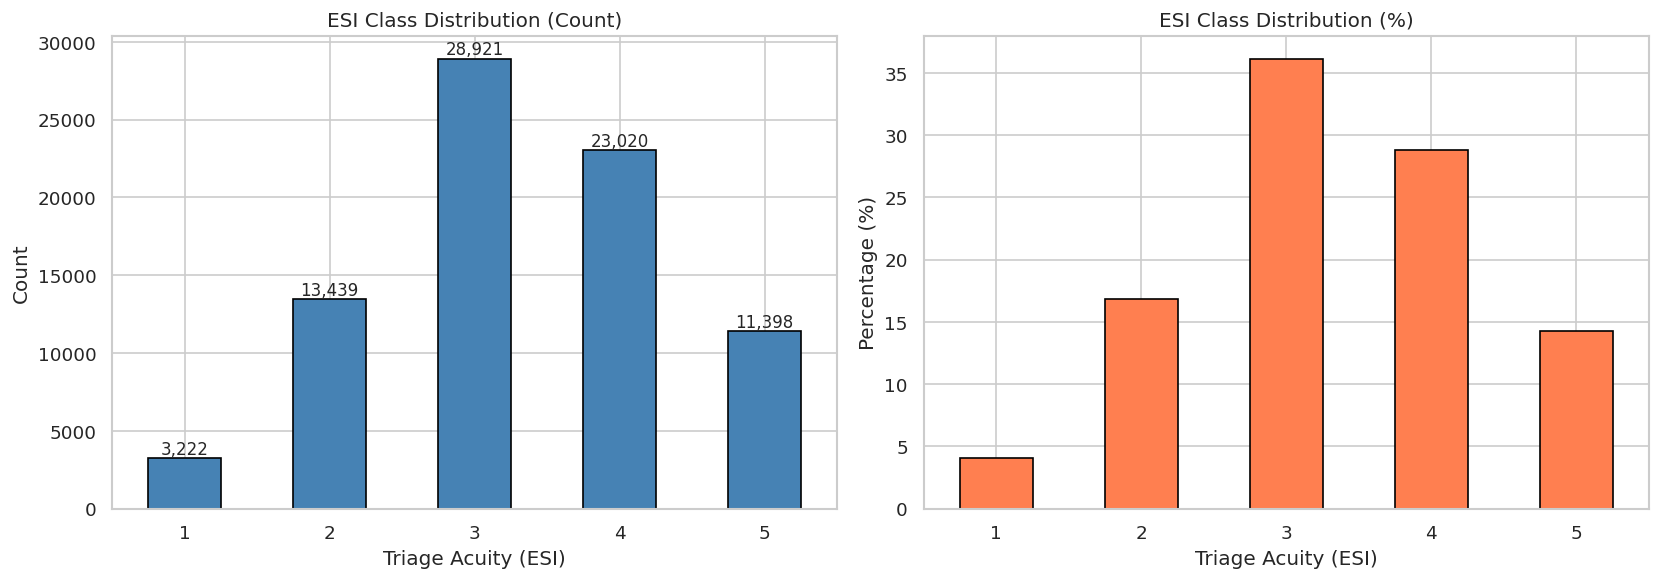

Class counts:
 triage_acuity
1     3222
2    13439
3    28921
4    23020
5    11398
Name: count, dtype: int64

Class %:
 triage_acuity
1     4.03
2    16.80
3    36.15
4    28.78
5    14.25
Name: count, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
y_train.value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('ESI Class Distribution (Count)')
axes[0].set_xlabel('Triage Acuity (ESI)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Add count labels on bars
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=10)

# Percentage plot
(y_train.value_counts().sort_index() / len(y_train) * 100).plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='black'
)
axes[1].set_title('ESI Class Distribution (%)')
axes[1].set_xlabel('Triage Acuity (ESI)')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('eda_class_distribution.png')
plt.show()

print("Class counts:\n", y_train.value_counts().sort_index())
print("\nClass %:\n", (y_train.value_counts().sort_index() / len(y_train) * 100).round(2))

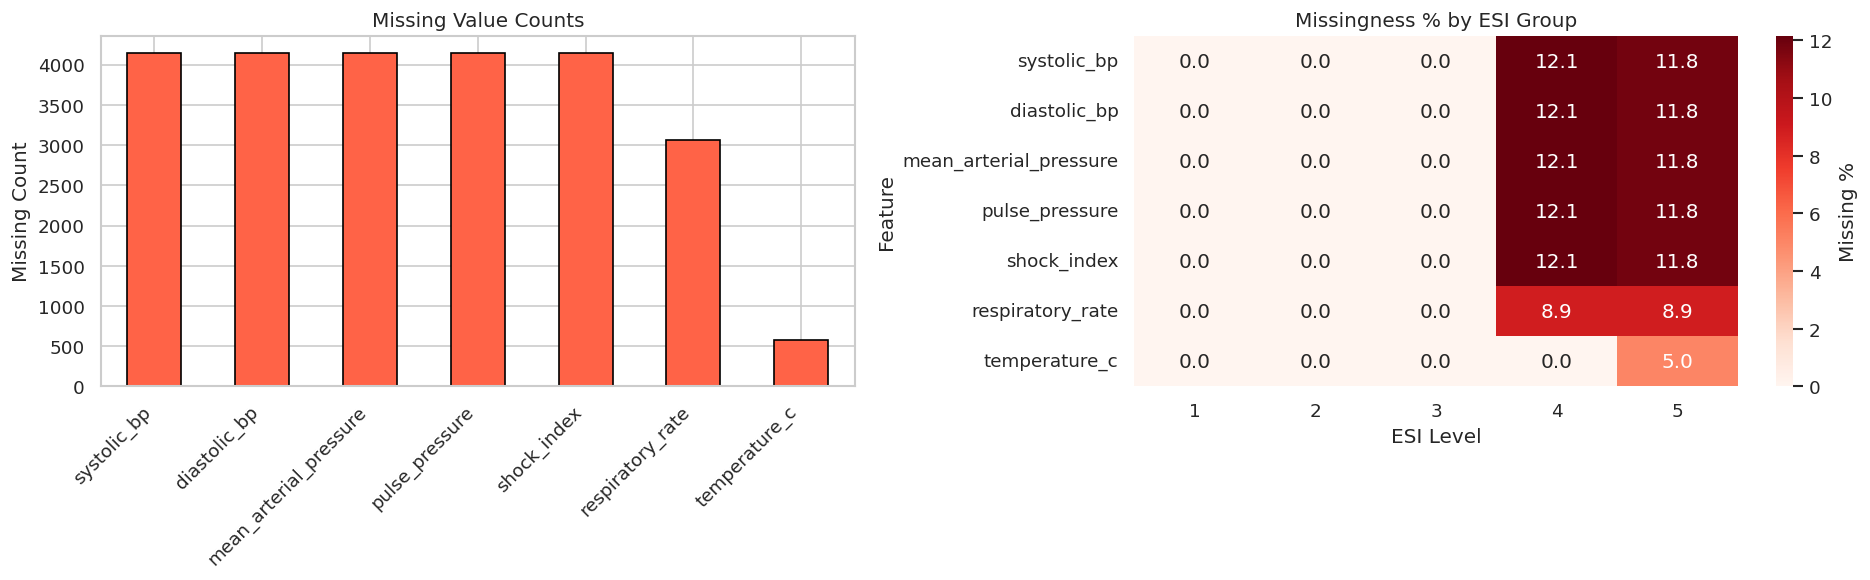

Missing value summary:
 systolic_bp               4146
diastolic_bp              4146
mean_arterial_pressure    4146
pulse_pressure            4146
shock_index               4146
respiratory_rate          3067
temperature_c              574
dtype: int64


In [7]:
# Overall missingness
missing = X_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart of missing counts
missing.plot(kind='bar', ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Missing Value Counts')
axes[0].set_ylabel('Missing Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# Missingness % by ESI group
train_with_target = X_train.copy()
train_with_target['triage_acuity'] = y_train.values

miss_by_esi = train_with_target.groupby('triage_acuity')[missing.index.tolist()].apply(
    lambda x: x.isnull().mean() * 100
)

sns.heatmap(miss_by_esi.T, annot=True, fmt='.1f', cmap='Reds',
            ax=axes[1], cbar_kws={'label': 'Missing %'})
axes[1].set_title('Missingness % by ESI Group')
axes[1].set_xlabel('ESI Level')
axes[1].set_ylabel('Feature')

plt.tight_layout()
plt.savefig('eda_missingness.png')
plt.show()

print("Missing value summary:\n", missing)

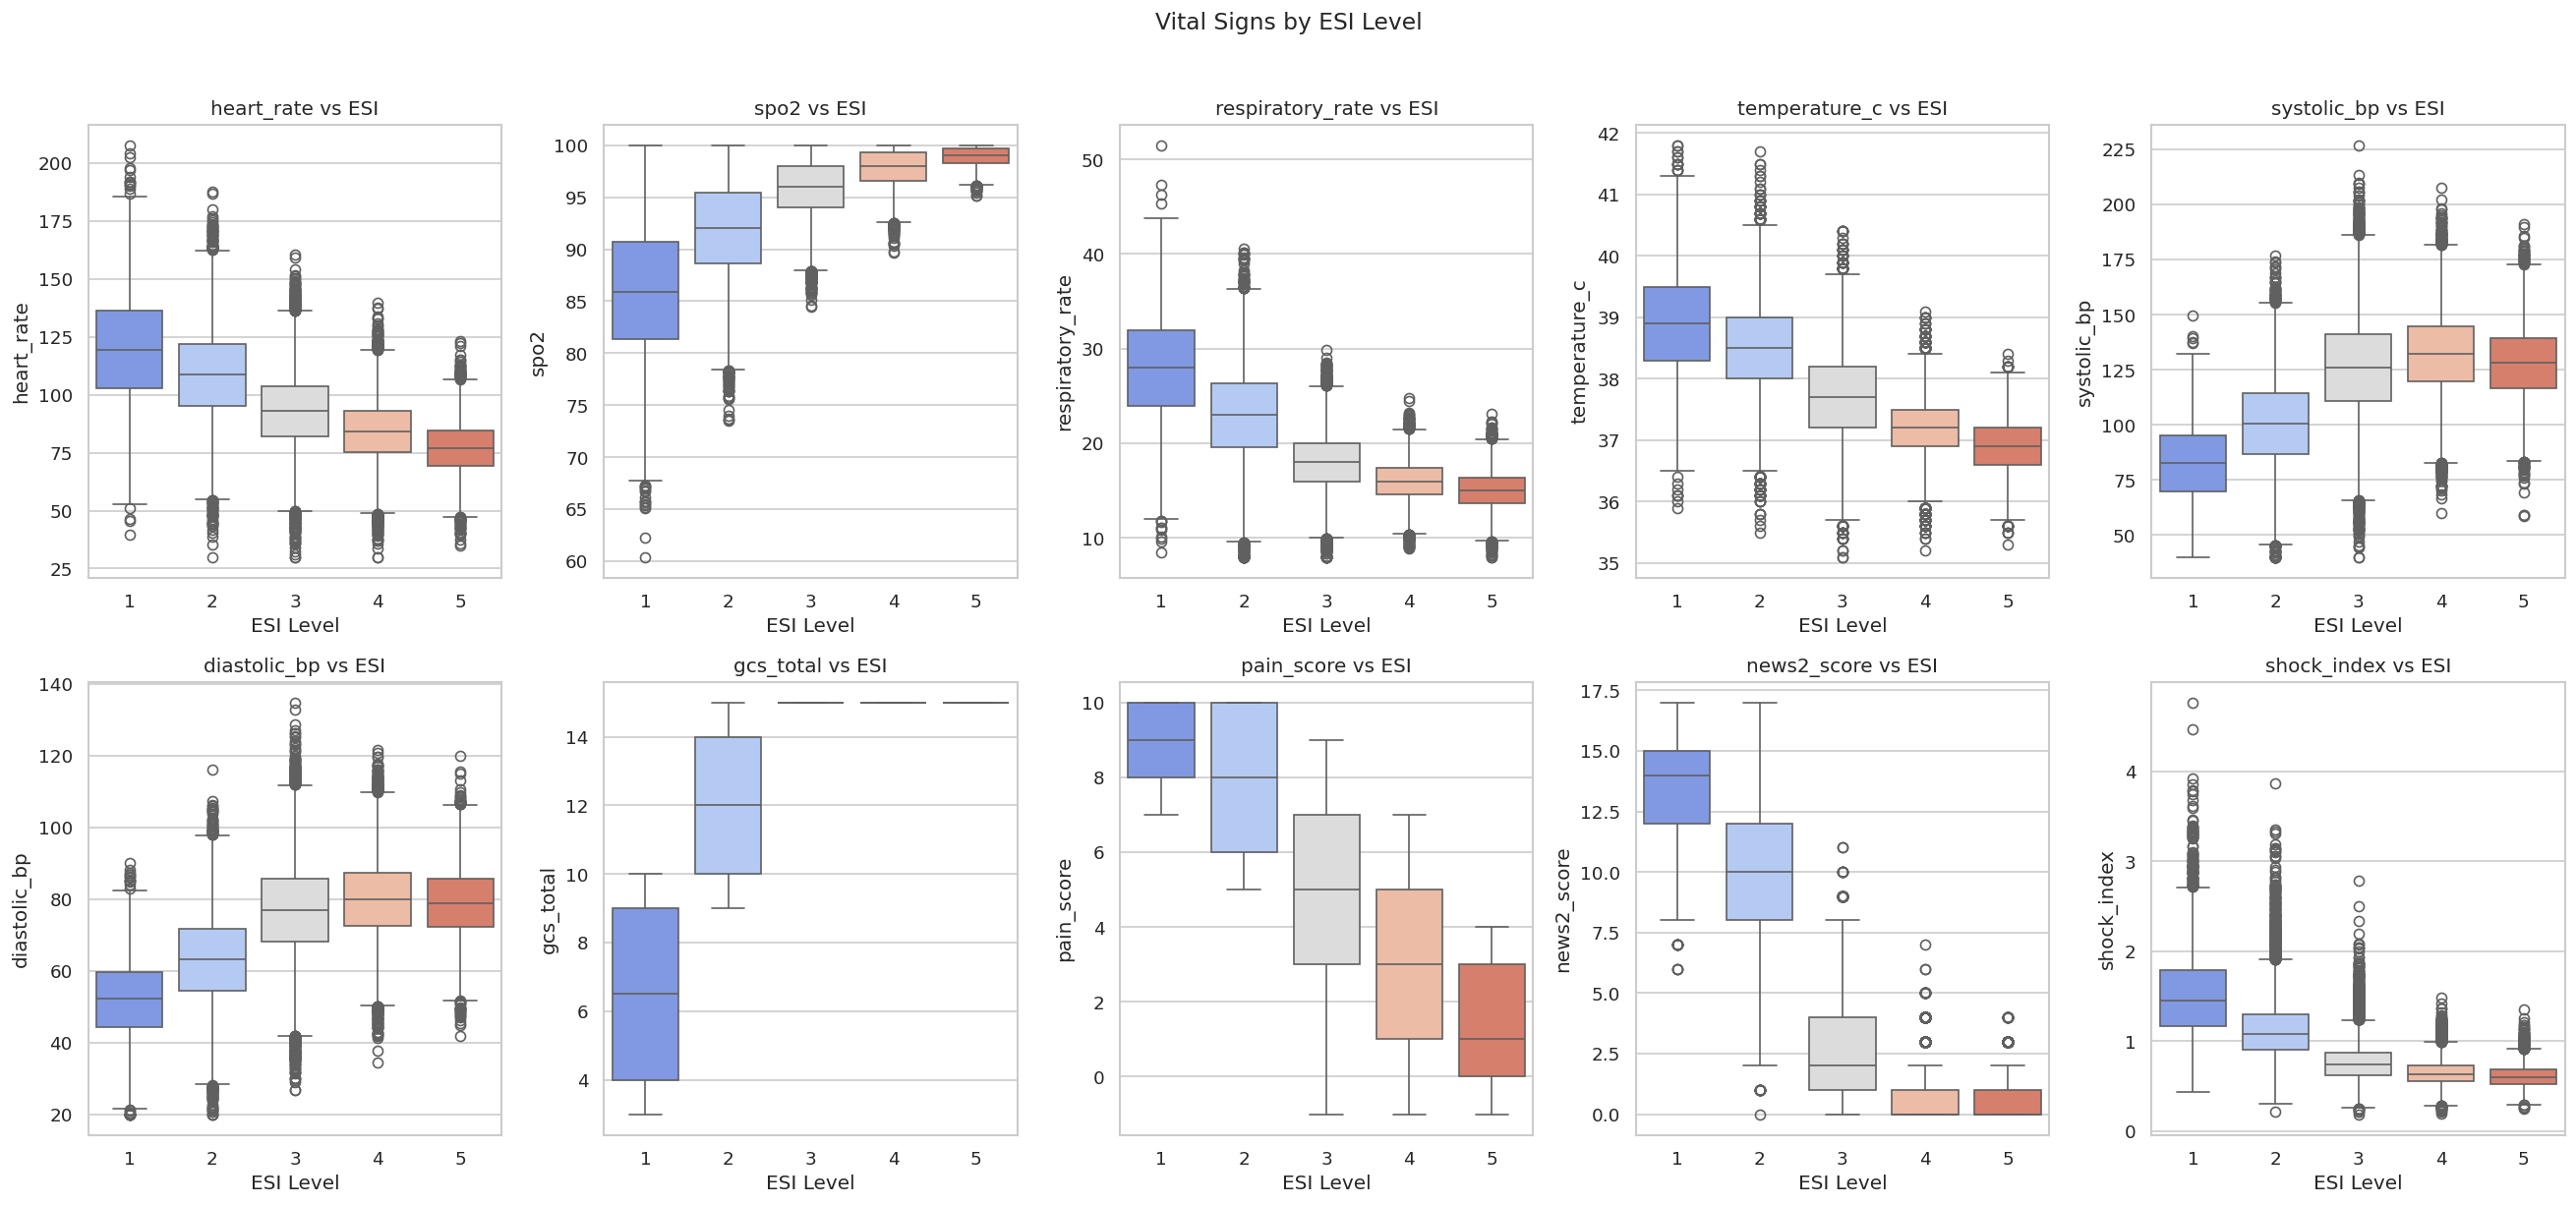

In [8]:
vital_cols = ['heart_rate', 'spo2', 'respiratory_rate',
              'temperature_c', 'systolic_bp', 'diastolic_bp',
              'gcs_total', 'pain_score', 'news2_score', 'shock_index']

train_plot = X_train[vital_cols].copy()
train_plot['triage_acuity'] = y_train.values

fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

for i, col in enumerate(vital_cols):
    sns.boxplot(data=train_plot, x='triage_acuity', y=col,
                ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'{col} vs ESI')
    axes[i].set_xlabel('ESI Level')
    axes[i].set_ylabel(col)

plt.suptitle('Vital Signs by ESI Level', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('eda_vitals_boxplots.png')
plt.show()

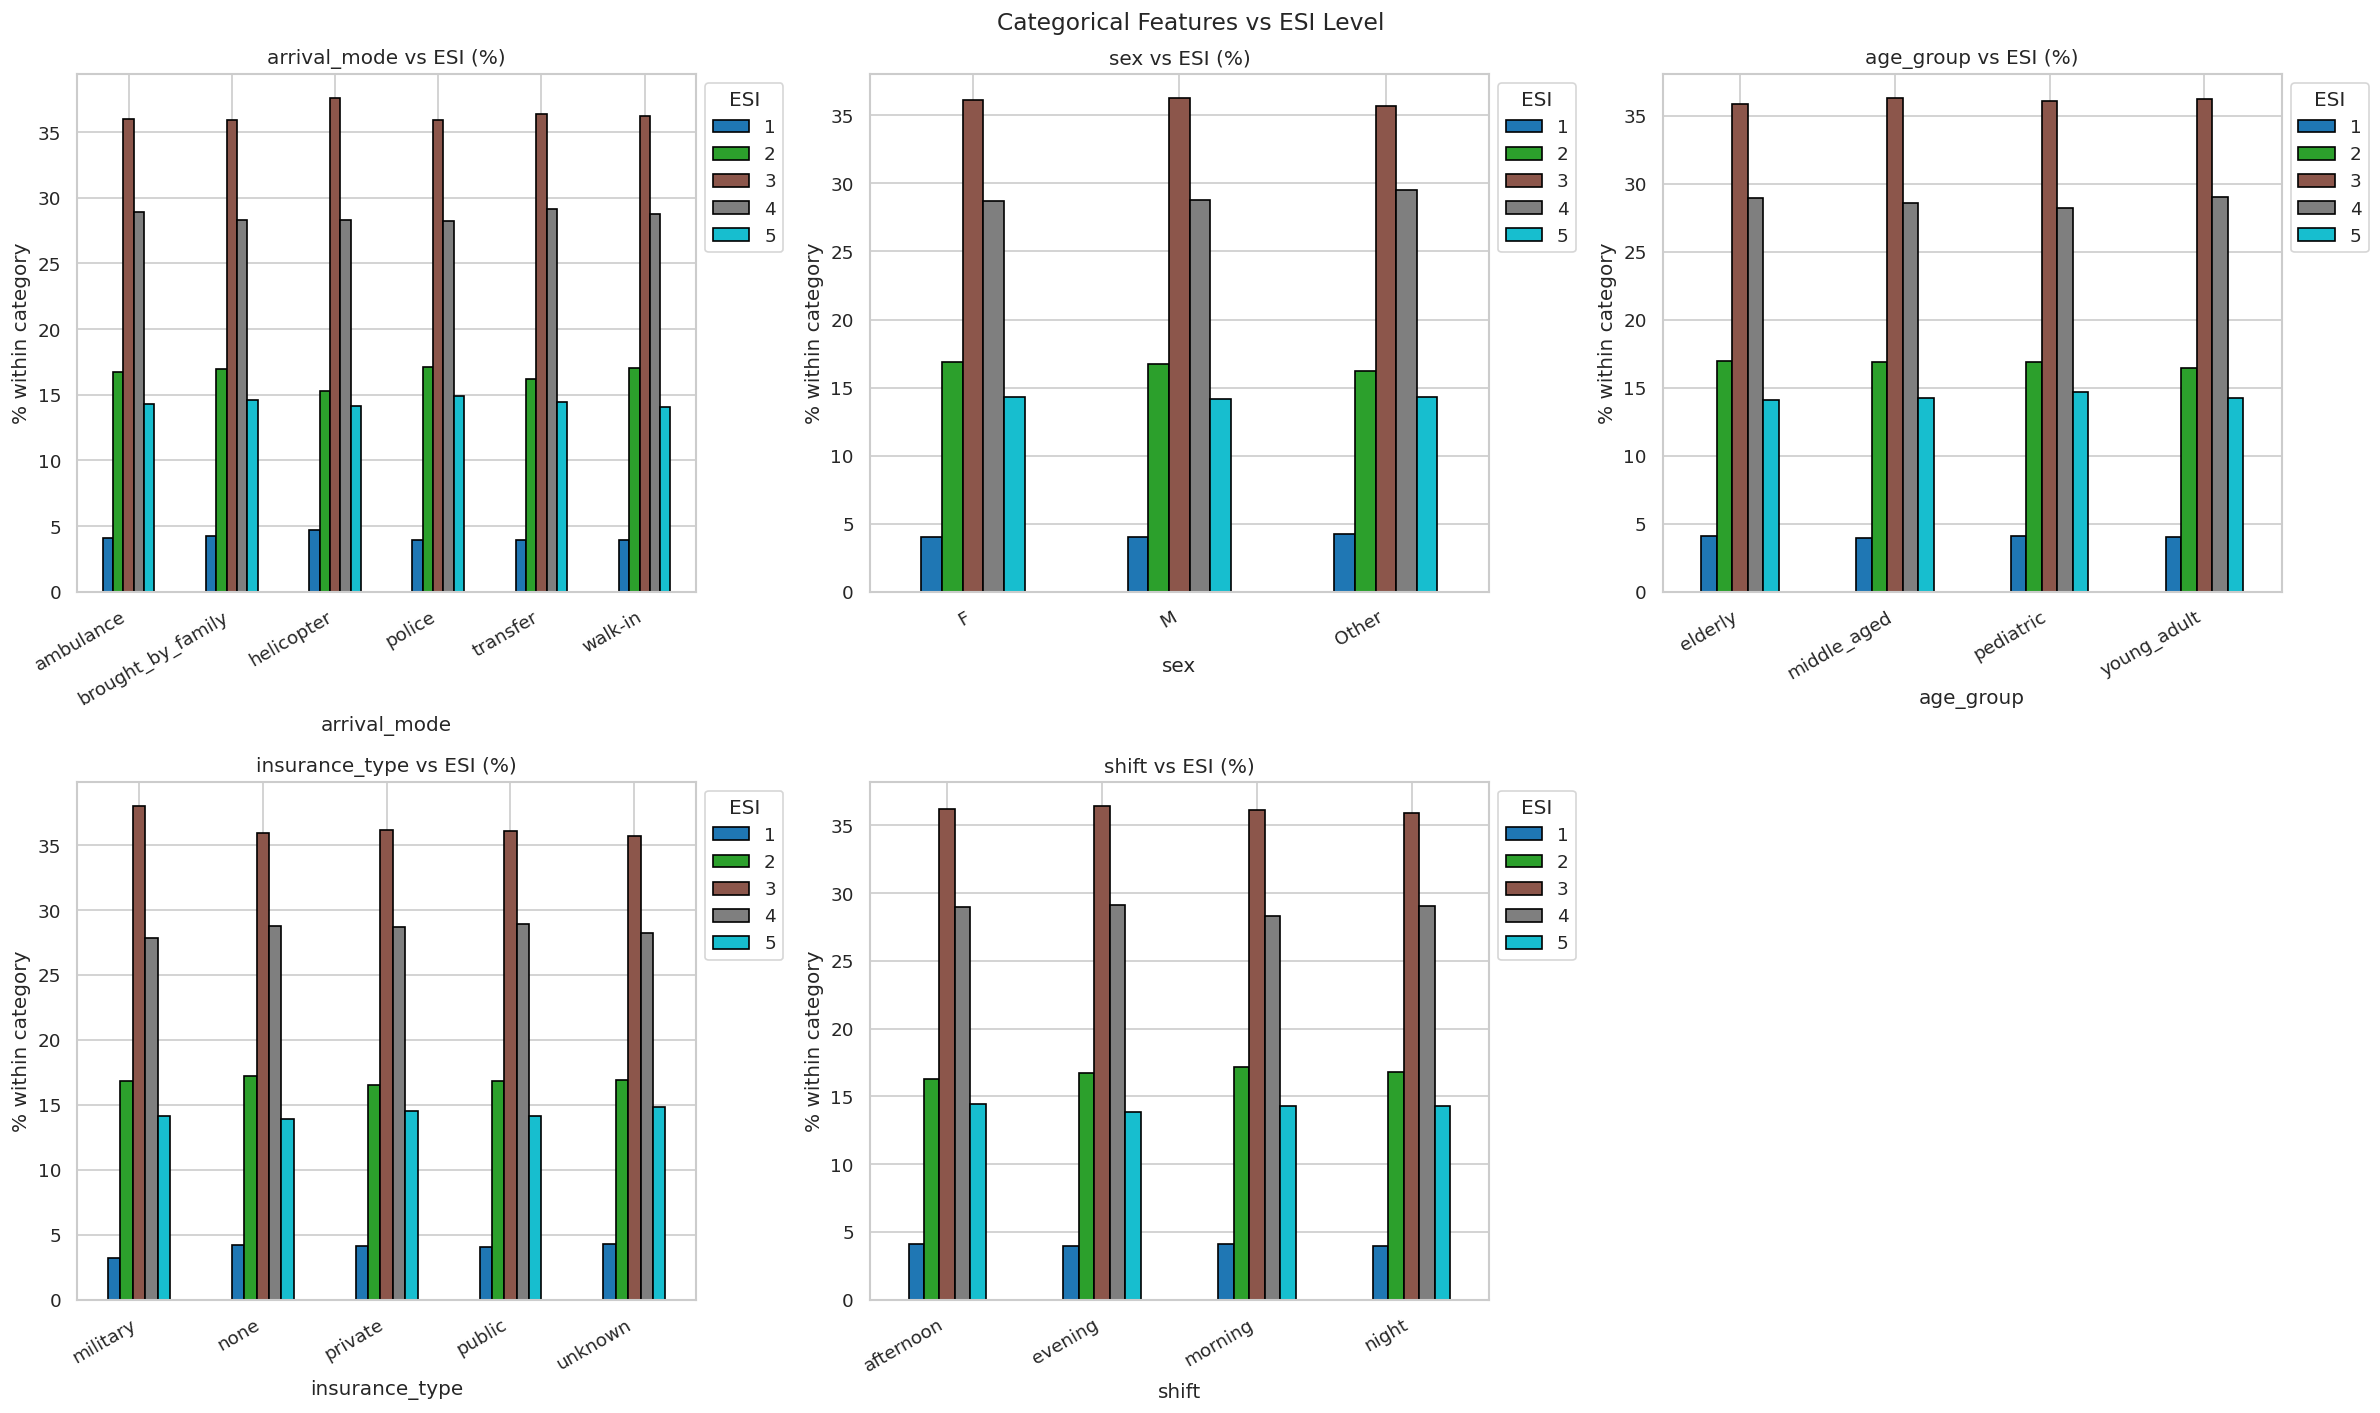

In [9]:
cat_cols = ['arrival_mode', 'sex', 'age_group', 'insurance_type', 'shift']

train_cat = X_train[cat_cols].copy()
train_cat['triage_acuity'] = y_train.values

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(train_cat[col], train_cat['triage_acuity'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], colormap='tab10', edgecolor='black')
    axes[i].set_title(f'{col} vs ESI (%)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('% within category')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].legend(title='ESI', bbox_to_anchor=(1, 1))

# Hide the last unused subplot
axes[-1].set_visible(False)

plt.suptitle('Categorical Features vs ESI Level', fontsize=14)
plt.tight_layout()
plt.savefig('eda_categorical.png')
plt.show()

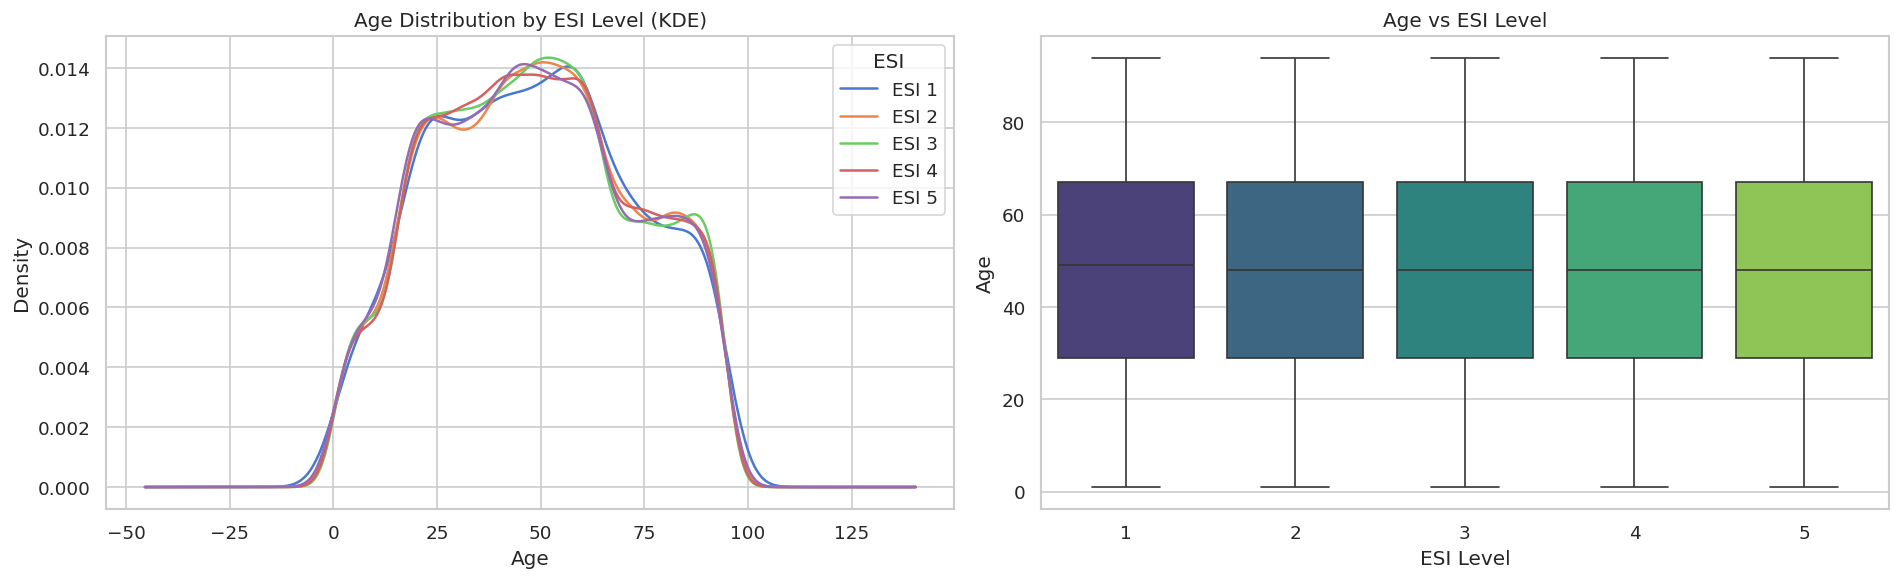

Median age by ESI:
 triage_acuity
1    49.0
2    48.0
3    48.0
4    48.0
5    48.0
Name: age, dtype: float64


In [10]:
train_age = X_train[['age']].copy()
train_age['triage_acuity'] = y_train.values

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# KDE plot of age by ESI
for esi in sorted(train_age['triage_acuity'].unique()):
    subset = train_age[train_age['triage_acuity'] == esi]['age']
    subset.plot(kind='kde', ax=axes[0], label=f'ESI {esi}')

axes[0].set_title('Age Distribution by ESI Level (KDE)')
axes[0].set_xlabel('Age')
axes[0].legend(title='ESI')

# Boxplot
sns.boxplot(data=train_age, x='triage_acuity', y='age',
            ax=axes[1], palette='viridis')
axes[1].set_title('Age vs ESI Level')
axes[1].set_xlabel('ESI Level')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.savefig('eda_age.png')
plt.show()

print("Median age by ESI:\n",
      train_age.groupby('triage_acuity')['age'].median())

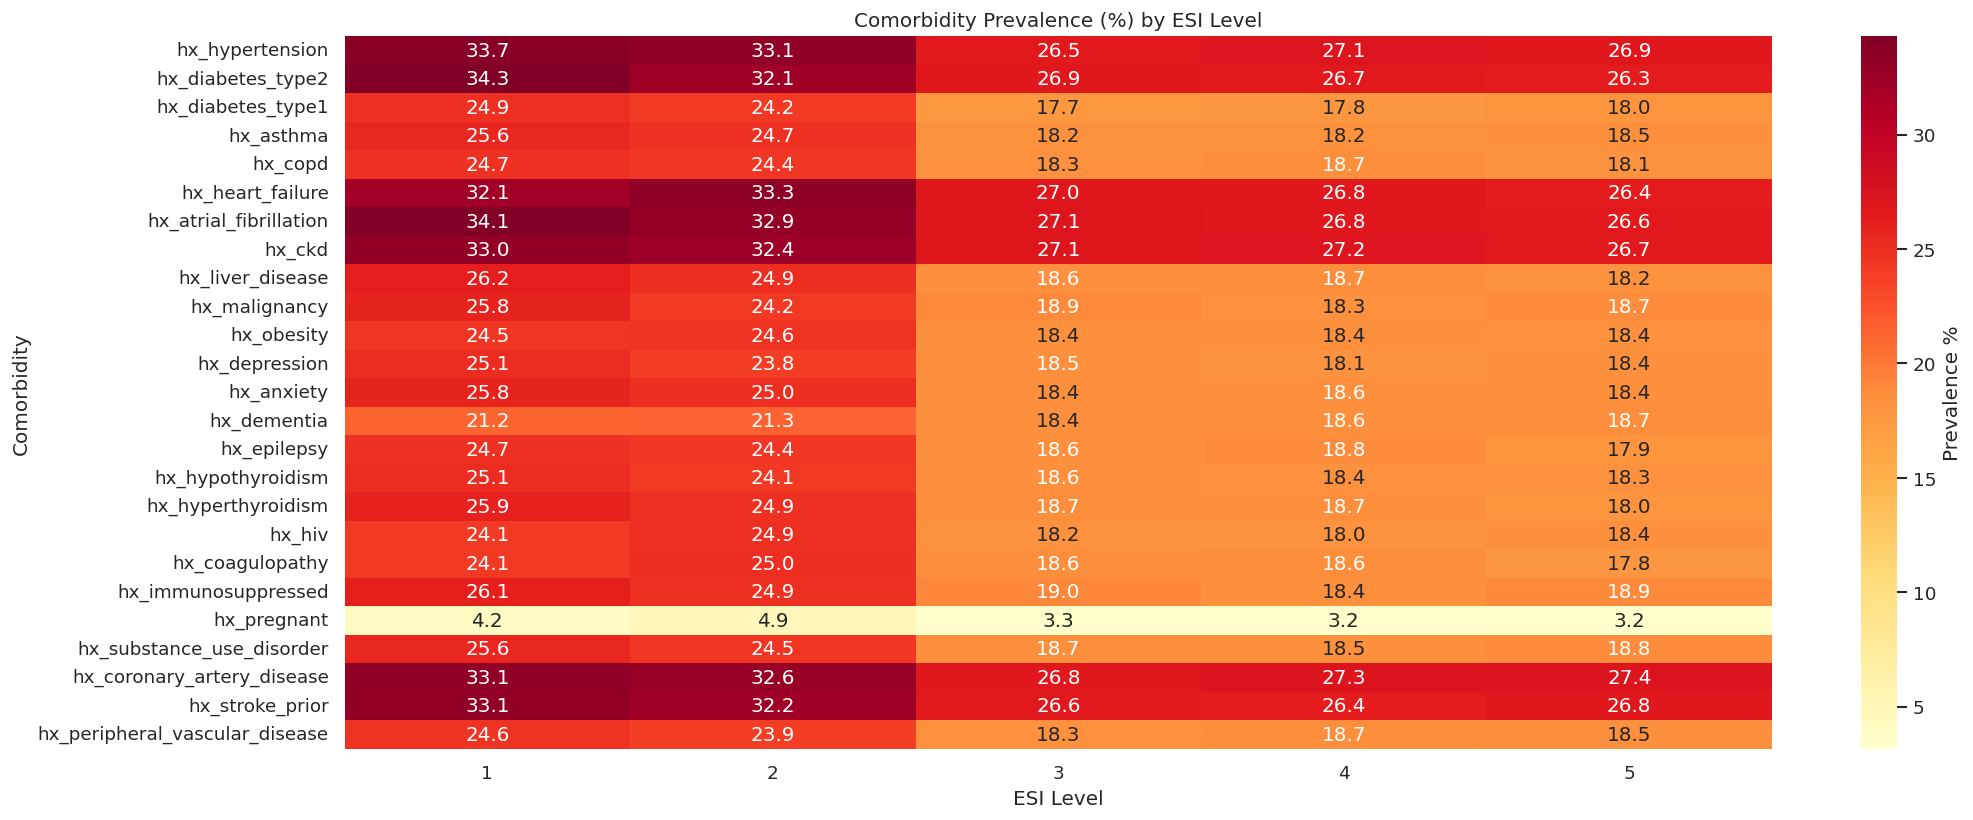

Overall comorbidity prevalence (%):
 hx_coronary_artery_disease        28.26
hx_atrial_fibrillation            28.21
hx_ckd                            28.18
hx_hypertension                   28.16
hx_heart_failure                  28.10
hx_diabetes_type2                 27.92
hx_stroke_prior                   27.76
hx_immunosuppressed               20.08
hx_hyperthyroidism                19.93
hx_liver_disease                  19.92
hx_substance_use_disorder         19.88
hx_anxiety                        19.87
hx_malignancy                     19.86
hx_coagulopathy                   19.80
hx_epilepsy                       19.77
hx_hypothyroidism                 19.68
hx_obesity                        19.67
hx_copd                           19.66
hx_asthma                         19.65
hx_peripheral_vascular_disease    19.64
hx_hiv                            19.56
hx_depression                     19.54
hx_diabetes_type1                 19.15
hx_dementia                       19.10
hx_

In [11]:
hx_cols = [c for c in X_train.columns if c.startswith('hx_')]

train_hx = X_train[hx_cols].copy()
train_hx['triage_acuity'] = y_train.values

# Comorbidity prevalence by ESI
hx_by_esi = train_hx.groupby('triage_acuity')[hx_cols].mean() * 100

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(hx_by_esi.T, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax, cbar_kws={'label': 'Prevalence %'})
ax.set_title('Comorbidity Prevalence (%) by ESI Level')
ax.set_xlabel('ESI Level')
ax.set_ylabel('Comorbidity')

plt.tight_layout()
plt.savefig('eda_comorbidities.png')
plt.show()

# Top comorbidities overall
print("Overall comorbidity prevalence (%):\n",
      (X_train[hx_cols].mean() * 100).sort_values(ascending=False).round(2))

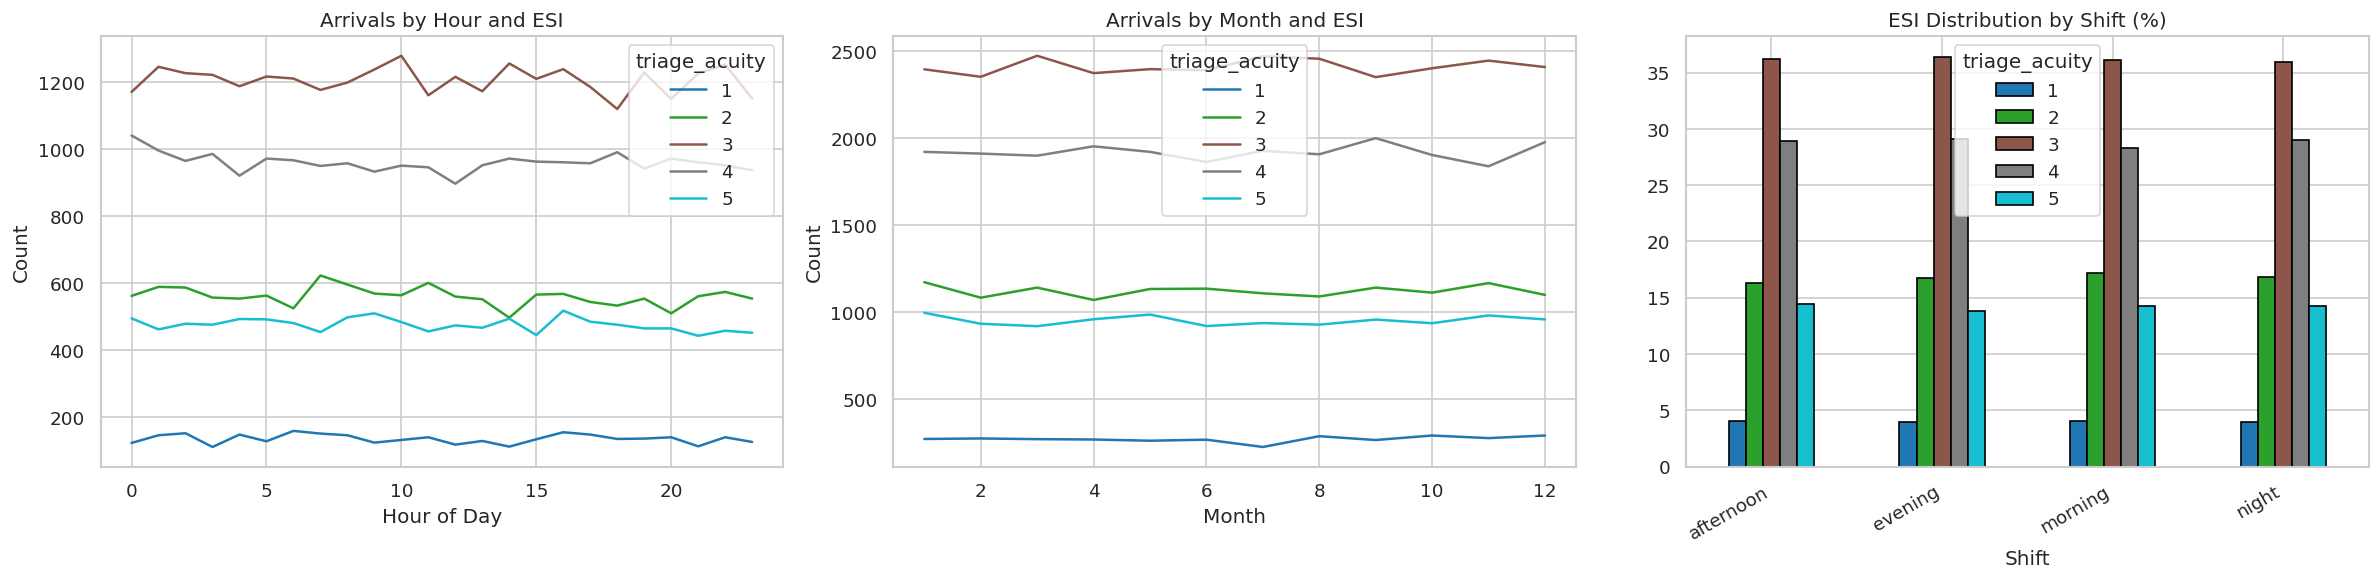

In [12]:
train_time = X_train[['arrival_hour', 'arrival_day', 'arrival_month', 'shift']].copy()
train_time['triage_acuity'] = y_train.values

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Arrival hour
hour_esi = train_time.groupby(['arrival_hour', 'triage_acuity']).size().unstack()
hour_esi.plot(ax=axes[0], colormap='tab10')
axes[0].set_title('Arrivals by Hour and ESI')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Count')

# Arrival month
month_esi = train_time.groupby(['arrival_month', 'triage_acuity']).size().unstack()
month_esi.plot(ax=axes[1], colormap='tab10')
axes[1].set_title('Arrivals by Month and ESI')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')

# Shift
shift_ct = pd.crosstab(train_time['shift'], train_time['triage_acuity'], normalize='index') * 100
shift_ct.plot(kind='bar', ax=axes[2], colormap='tab10', edgecolor='black')
axes[2].set_title('ESI Distribution by Shift (%)')
axes[2].set_xlabel('Shift')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('eda_temporal.png')
plt.show()

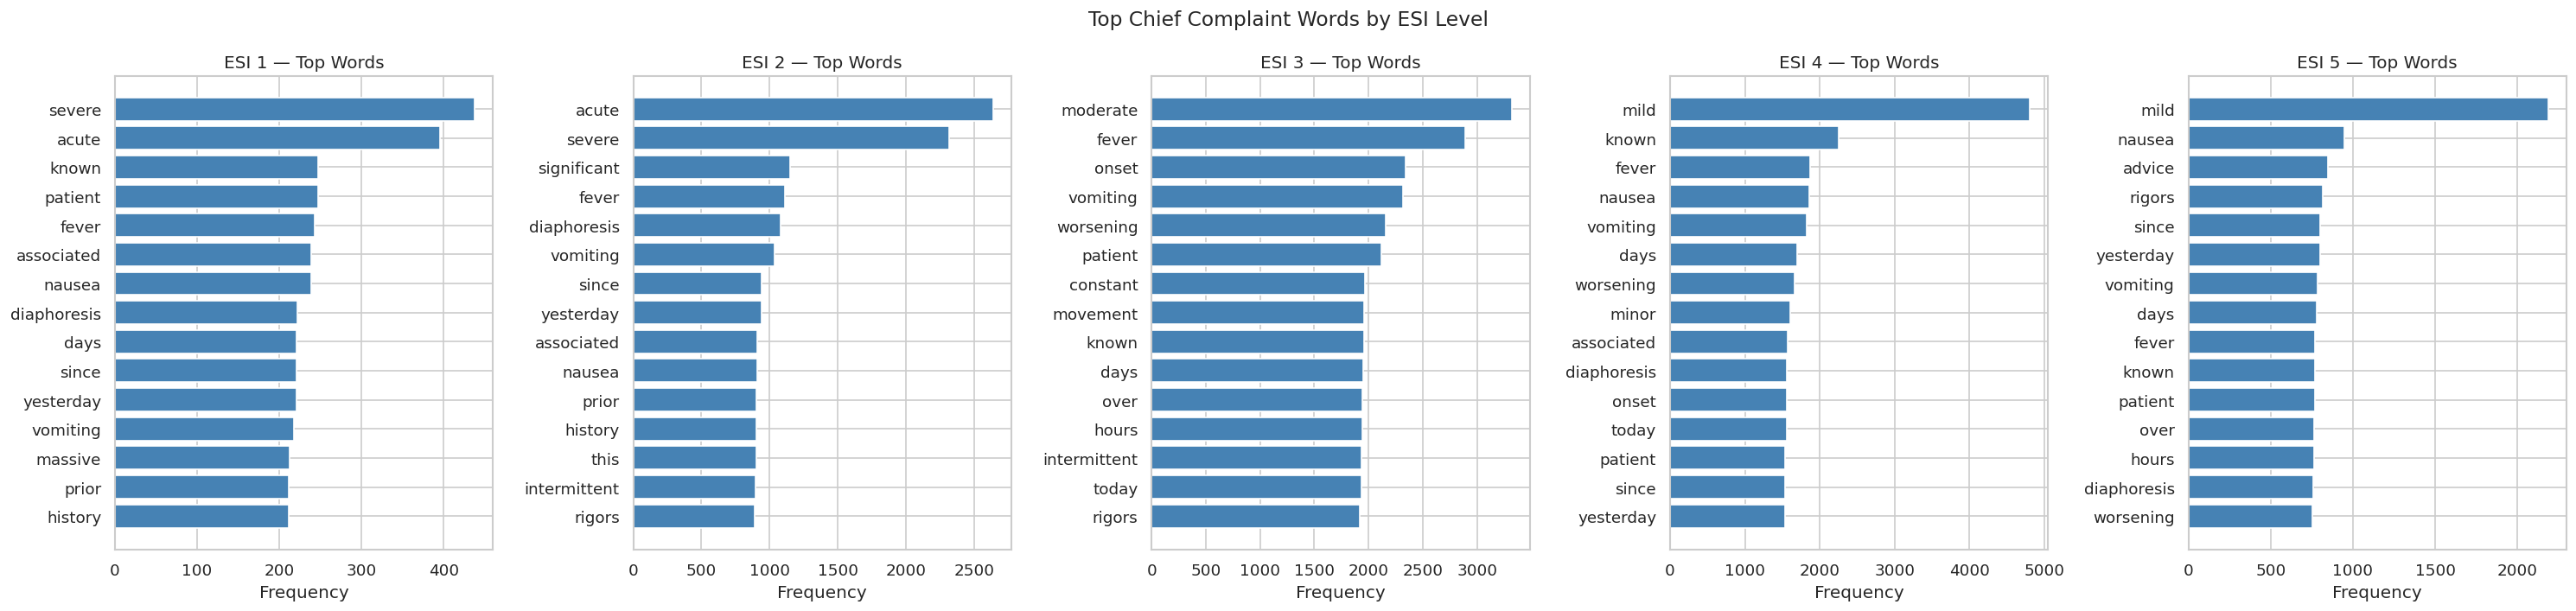

In [13]:
from collections import Counter

train_text_df = pd.DataFrame({
    'complaint_text': train_text.values,
    'triage_acuity': y_train.values
})

fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for esi in range(1, 6):
    subset = train_text_df[train_text_df['triage_acuity'] == esi]['complaint_text']
    words = ' '.join(subset.dropna()).lower().split()
    # Remove very generic words
    stopwords = {'the', 'a', 'and', 'of', 'to', 'in', 'with', 'no', 'for', 'on'}
    words = [w for w in words if w not in stopwords and len(w) > 2]
    top_words = Counter(words).most_common(15)

    words_list, counts = zip(*top_words)
    axes[esi-1].barh(words_list[::-1], counts[::-1], color='steelblue')
    axes[esi-1].set_title(f'ESI {esi} — Top Words')
    axes[esi-1].set_xlabel('Frequency')

plt.suptitle('Top Chief Complaint Words by ESI Level', fontsize=14)
plt.tight_layout()
plt.savefig('eda_complaints_wordfreq.png')
plt.show()

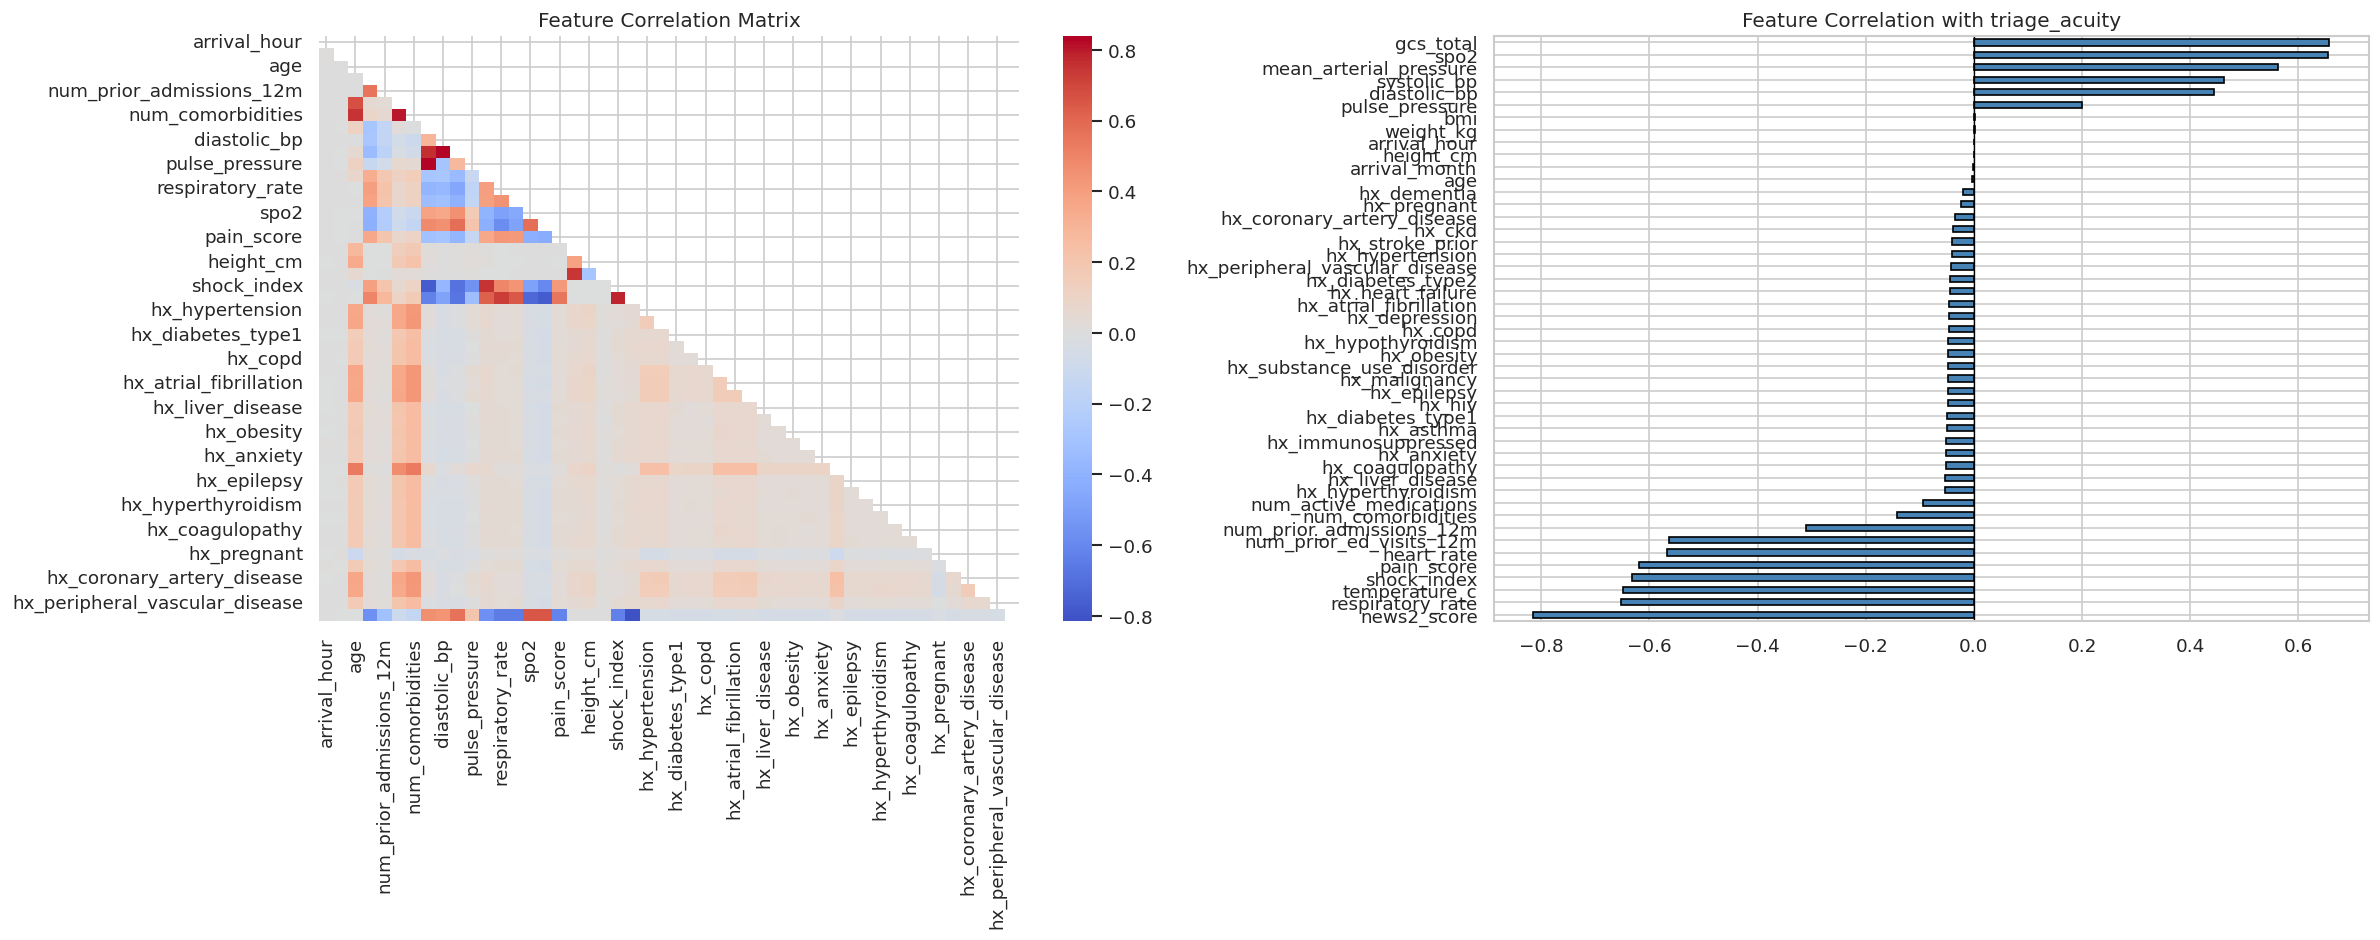

Top 10 features correlated with target:
 news2_score                0.814804
gcs_total                  0.656620
spo2                       0.654399
respiratory_rate           0.652945
temperature_c              0.649193
shock_index                0.631830
pain_score                 0.618834
heart_rate                 0.567962
num_prior_ed_visits_12m    0.564138
mean_arterial_pressure     0.561726
Name: triage_acuity, dtype: float64


In [14]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

train_corr = X_train[numeric_cols].copy()
train_corr['triage_acuity'] = y_train.values

corr_matrix = train_corr.corr()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Full heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
            ax=axes[0], fmt='.1f', annot=False)
axes[0].set_title('Feature Correlation Matrix')

# Correlation with target only
target_corr = corr_matrix['triage_acuity'].drop('triage_acuity').sort_values()
target_corr.plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Feature Correlation with triage_acuity')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('eda_correlation.png')
plt.show()

print("Top 10 features correlated with target:\n",
      target_corr.abs().sort_values(ascending=False).head(10))

In [15]:
vital_cols = ['heart_rate', 'spo2', 'respiratory_rate', 'temperature_c',
              'systolic_bp', 'diastolic_bp', 'gcs_total', 'pain_score',
              'age', 'bmi', 'weight_kg', 'height_cm']

print("=== Outlier / Range Check ===\n")
for col in vital_cols:
    if col in X_train.columns:
        print(f"{col}:")
        print(f"  min={X_train[col].min():.1f}, "
              f"max={X_train[col].max():.1f}, "
              f"mean={X_train[col].mean():.1f}, "
              f"null={X_train[col].isnull().sum()}")

# Pain score -1 sentinel
print("\nPain score -1 count:", (X_train['pain_score'] == -1).sum())
print("Pain score distribution:\n", X_train['pain_score'].value_counts().sort_index())

=== Outlier / Range Check ===

heart_rate:
  min=30.0, max=207.7, mean=91.9, null=0
spo2:
  min=60.4, max=100.0, mean=95.8, null=0
respiratory_rate:
  min=8.0, max=51.5, mean=18.3, null=3067
temperature_c:
  min=35.1, max=41.8, mean=37.6, null=574
systolic_bp:
  min=40.0, max=226.9, mean=121.6, null=4146
diastolic_bp:
  min=20.0, max=134.8, mean=74.5, null=4146
gcs_total:
  min=3.0, max=15.0, mean=14.2, null=0
pain_score:
  min=-1.0, max=10.0, mean=4.5, null=0
age:
  min=1.0, max=94.0, mean=48.5, null=0
bmi:
  min=10.0, max=65.0, mean=26.4, null=0
weight_kg:
  min=2.0, max=148.5, mean=74.5, null=0
height_cm:
  min=45.0, max=210.0, mean=168.6, null=0

Pain score -1 count: 11156
Pain score distribution:
 pain_score
-1     11156
 0      1922
 1      4488
 2      4626
 3      7918
 4      8044
 5      8086
 6      7986
 7      8761
 8      5963
 9      5913
 10     5137
Name: count, dtype: int64


In [16]:
# Replace -1 sentinel with NaN, then add a missing flag
X_train['pain_missing'] = (X_train['pain_score'] == -1).astype(int)
X_test['pain_missing']  = (X_test['pain_score']  == -1).astype(int)

X_train['pain_score'] = X_train['pain_score'].replace(-1, float('nan'))
X_test['pain_score']  = X_test['pain_score'].replace(-1, float('nan'))

# Fill NaN with median from training data
pain_median = X_train['pain_score'].median()
X_train['pain_score'] = X_train['pain_score'].fillna(pain_median)
X_test['pain_score']  = X_test['pain_score'].fillna(pain_median)

print("Pain missing flag count:", X_train['pain_missing'].sum())
print("Pain score nulls after fix:", X_train['pain_score'].isnull().sum())

Pain missing flag count: 11156
Pain score nulls after fix: 0


In [17]:
from sklearn.preprocessing import LabelEncoder

# Identify all object/string columns in feature set
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", cat_cols)

# Label encode each one
le_dict = {}  # save encoders for test set
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined train+test to avoid unseen label errors
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    le_dict[col] = le

print("Encoding done. Sample dtypes:\n", X_train.dtypes.value_counts())

Categorical columns to encode: ['arrival_mode', 'arrival_day', 'arrival_season', 'shift', 'age_group', 'sex', 'language', 'insurance_type', 'transport_origin', 'pain_location', 'mental_status_triage']
Encoding done. Sample dtypes:
 int64      46
float64    13
Name: count, dtype: int64


In [18]:
# Simple median fill for baseline — no ESI-awareness yet
for col in X_train.columns:
    if X_train[col].isnull().sum() > 0:
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        X_test[col]  = X_test[col].fillna(median_val)

print("Nulls after imputation:", X_train.isnull().sum().sum())

Nulls after imputation: 0


In [19]:
import lightgbm as lgb
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, cohen_kappa_score, accuracy_score

# Adjust target to 0-indexed (LightGBM needs 0,1,2,3,4 not 1,2,3,4,5)
y = y_train.values - 1

# Class weights to handle ESI 1 rarity
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(y)
weights = compute_class_weight('balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))
print("Class weights:", class_weight_dict)

# Sample weights array
sample_weights = np.array([class_weight_dict[yi] for yi in y])

# LightGBM baseline params
params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_logloss',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros((len(X_train), 5))  # out-of-fold probabilities
test_preds = np.zeros((len(X_test), 5))  # test predictions

fold_f1s   = []
fold_kappas = []
fold_accs  = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y)):
    print(f"\n--- Fold {fold+1}/5 ---")

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    sw_tr = sample_weights[train_idx]

    dtrain = lgb.Dataset(X_tr, label=y_tr, weight=sw_tr)
    dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain)

    model = lgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        valid_sets=[dval],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=100)
        ]
    )

    # OOF predictions
    val_proba = model.predict(X_val)
    oof_preds[val_idx] = val_proba
    val_pred_labels = np.argmax(val_proba, axis=1)

    # Test predictions (average across folds)
    test_preds += model.predict(X_test) / 5

    # Metrics
    f1   = f1_score(y_val, val_pred_labels, average='weighted')
    kappa = cohen_kappa_score(y_val, val_pred_labels, weights='quadratic')
    acc  = accuracy_score(y_val, val_pred_labels)

    fold_f1s.append(f1)
    fold_kappas.append(kappa)
    fold_accs.append(acc)

    print(f"Fold {fold+1} — Weighted F1: {f1:.4f} | QWK: {kappa:.4f} | Acc: {acc:.4f}")

# Overall OOF scores
oof_labels = np.argmax(oof_preds, axis=1)
oof_f1    = f1_score(y, oof_labels, average='weighted')
oof_kappa = cohen_kappa_score(y, oof_labels, weights='quadratic')
oof_acc   = accuracy_score(y, oof_labels)

print("\n========== BASELINE RESULTS ==========")
print(f"OOF Weighted F1 : {oof_f1:.4f}")
print(f"OOF QWK         : {oof_kappa:.4f}")
print(f"OOF Accuracy    : {oof_acc:.4f}")
print(f"Mean Fold F1    : {np.mean(fold_f1s):.4f} ± {np.std(fold_f1s):.4f}")
print(f"Mean Fold QWK   : {np.mean(fold_kappas):.4f} ± {np.std(fold_kappas):.4f}")
print("======================================")

# Per-class F1
from sklearn.metrics import classification_report
print("\nPer-class report:")
print(classification_report(y, oof_labels,
      target_names=['ESI 1','ESI 2','ESI 3','ESI 4','ESI 5']))

Class weights: {np.int64(0): np.float64(4.9658597144630665), np.int64(1): np.float64(1.1905647741647445), np.int64(2): np.float64(0.5532312160713668), np.int64(3): np.float64(0.6950477845351868), np.int64(4): np.float64(1.403755044744692)}

--- Fold 1/5 ---
[100]	valid_0's multi_logloss: 0.338282
[200]	valid_0's multi_logloss: 0.333265
Fold 1 — Weighted F1: 0.8525 | QWK: 0.9308 | Acc: 0.8521

--- Fold 2/5 ---
[100]	valid_0's multi_logloss: 0.347314
[200]	valid_0's multi_logloss: 0.340593
Fold 2 — Weighted F1: 0.8475 | QWK: 0.9274 | Acc: 0.8468

--- Fold 3/5 ---
[100]	valid_0's multi_logloss: 0.33792
[200]	valid_0's multi_logloss: 0.330949
Fold 3 — Weighted F1: 0.8526 | QWK: 0.9287 | Acc: 0.8518

--- Fold 4/5 ---
[100]	valid_0's multi_logloss: 0.339254
[200]	valid_0's multi_logloss: 0.333374
Fold 4 — Weighted F1: 0.8525 | QWK: 0.9308 | Acc: 0.8518

--- Fold 5/5 ---
[100]	valid_0's multi_logloss: 0.34445
[200]	valid_0's multi_logloss: 0.337825
Fold 5 — Weighted F1: 0.8495 | QWK: 0.9289 |

In [21]:
import json
import os

baseline_scores = {
    'version': 'v1_baseline',
    'model': 'LightGBM',
    'features': 'structured_only_no_nlp',
    'oof_weighted_f1': round(oof_f1, 4),
    'oof_qwk': round(oof_kappa, 4),
    'oof_accuracy': round(oof_acc, 4),
    'feature_count': X_train.shape[1]
}

print("Baseline scores:", json.dumps(baseline_scores, indent=2))

# Ensure the directory exists before saving
output_dir = '/kaggle/working/'
os.makedirs(output_dir, exist_ok=True)

# Save OOF predictions for Phase 2 stacking
np.save(os.path.join(output_dir, 'oof_baseline.npy'), oof_preds)
np.save(os.path.join(output_dir, 'test_baseline.npy'), test_preds)

print("OOF and test predictions saved.")

Baseline scores: {
  "version": "v1_baseline",
  "model": "LightGBM",
  "features": "structured_only_no_nlp",
  "oof_weighted_f1": 0.8509,
  "oof_qwk": 0.9293,
  "oof_accuracy": 0.8503,
  "feature_count": 59
}
OOF and test predictions saved.


In [22]:
# Convert back to 1-indexed ESI
baseline_submission = pd.DataFrame({
    'patient_id': test['patient_id'],
    'triage_acuity': np.argmax(test_preds, axis=1) + 1
})

baseline_submission.to_csv('/kaggle/working/submission_baseline.csv', index=False)
print("Baseline submission saved.")
print("Predicted distribution:\n",
      baseline_submission['triage_acuity'].value_counts().sort_index())

Baseline submission saved.
Predicted distribution:
 triage_acuity
1     766
2    3382
3    6965
4    5539
5    3348
Name: count, dtype: int64
